In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix
from nltk.tokenize import word_tokenize
from keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.models import Model
from keras.layers import Input, Dense, LSTM, Dropout, concatenate
from tensorflow.keras.layers import Embedding
from keras.utils import plot_model

In [ ]:
df = pd.read_csv("/content/input/all_agree.csv")
df.head()

,title,label,label_score
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",non-clickbait,0
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,non-clickbait,0
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,clickbait,1
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",non-clickbait,0
4,MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...,non-clickbait,0


In [ ]:
df['label_score'].value_counts()

,count
label_score,
0,5297
1,3316


In [ ]:
df['excl_count'] = df['title'].apply(lambda x: find_punc(x, '!'))
df['ques_count'] = df['title'].apply(lambda x: find_punc(x, '?'))
df['comma_count'] = df['title'].apply(lambda x: find_punc(x, ','))
df['colon_count'] = df['title'].apply(lambda x: find_punc(x, ':'))
df['caps_count'] = df['title'].apply(lambda x: sum(1 for c in x if c.isupper()))
df['num_count'] = df['title'].apply(lambda x: sum(1 for c in x if c.isdigit()))
df['title_len'] = df['title'].apply(len)

def finde_uppercase(x):
  count = 0
  for chart in x:
    if chart.isupper():
      count += 1
  return count

def find_lowercase(x):
  count = 0
  for chart in x:
    if chart.islower():
      count += 1
  return count

def find_numbers(x):
  return len(re.findall('[0-9]',x))

df['uppercase_count'] = df['title'].apply(lambda x: finde_uppercase(x))
df['lowercase_count'] = df['title'].apply(lambda x: find_lowercase(x))
df['numbers_count'] = df['title'].apply(lambda x: find_numbers(x))
df.shape
# df.head()

(8613, 13)

In [ ]:
def find_punc(x, punc):
  count = 0
  for chart in x:
    if chart in punc:
      count += 1
  return count
df.shape

(8613, 3)

In [ ]:
def clean(text):
  text = text.lower()
  # Menggunakan raw string r'' dan memperbaiki penutupan tanda kutip serta argumen re.sub
  text = re.sub(r'[,.!?:;\\\]]', '', text)
  word_tokens = word_tokenize(text)
  # Menggunakan spasi ' '.join jika ingin memisahkan kata, atau ''.join sesuai kode asli Anda
  text = (' '.join(word_tokens))
  return text

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

df['cleaned_title'] = df['title'].apply(clean)
df[['title', 'cleaned_title']]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,title,cleaned_title
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",masuk radar pilwalkot medan menantu jokowi ber...
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,malaysia sudutkan ri isu kabut asap hingga inv...
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,viral driver ojol di bekasi antar pesanan maka...
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",kemensos salurkan rp 73 m bagi korban kerusuha...
4,MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...,mpr amandemen uud 1945 tak akan melebar ke man...
...,...,...
8608,Twice Rilis Teaser MV 'Feel Special' Jelang Co...,twice rilis teaser mv 'feel special ' jelang c...
8609,"Asap Karhutla Riau Mulai Merambah Ke Nias, BM...",asap karhutla riau mulai merambah ke nias bmkg...
8610,"Tolak RUU Pertanahan, Ribuan Petani Siap Gelar...",tolak ruu pertanahan ribuan petani siap gelar ...
8611,Ada Niat Tambah Momongan Tanpa Ikut Program Ha...,ada niat tambah momongan tanpa ikut program ha...


In [ ]:
df.columns

Index(['title', 'label', 'label_score', 'excl_count', 'ques_count',
       'comma_count', 'colon_count', 'caps_count', 'num_count', 'title_len',
       'uppercase_count', 'lowercase_count', 'numbers_count', 'cleaned_title'],
      dtype='object')

In [ ]:
x = df.iloc[:,3:]
y = df.iloc[:,2]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=77)

print(x_train.shape)
print(x_test.shape)

(6890, 11)
(1723, 11)


In [ ]:
x_train_title = x_train['cleaned_title']
x_test_title = x_test['cleaned_title']

x_train_punc = x_train.drop('cleaned_title', axis=1)
x_test_punc = x_test.drop('cleaned_title', axis=1)

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(x_train_title)

x_train_title = tokenizer.texts_to_sequences(x_train_title)
x_test_title = tokenizer.texts_to_sequences(x_test_title)


In [ ]:
tokenizer.word_index

{'di': 1,
 'ini': 2,
 'dan': 3,
 'yang': 4,
 "'": 5,
 'ke': 6,
 'jadi': 7,
 'kpk': 8,
 '2019': 9,
 'indonesia': 10,
 'tak': 11,
 'untuk': 12,
 'dengan': 13,
 'habibie': 14,
 'dari': 15,
 'dpr': 16,
 'polisi': 17,
 'jokowi': 18,
 'saat': 19,
 'soal': 20,
 'akan': 21,
 'uu': 22,
 'baru': 23,
 'minta': 24,
 'anak': 25,
 'ada': 26,
 'mahasiswa': 27,
 'bisa': 28,
 'hingga': 29,
 'demo': 30,
 'bikin': 31,
 '3': 32,
 'asap': 33,
 'vs': 34,
 'kota': 35,
 'revisi': 36,
 '5': 37,
 'gara': 38,
 'hari': 39,
 'papua': 40,
 'bj': 41,
 '4': 42,
 'tahun': 43,
 '2': 44,
 'usai': 45,
 'liga': 46,
 'sebut': 47,
 'warga': 48,
 'bakal': 49,
 'orang': 50,
 'rumah': 51,
 'sinopsis': 52,
 '1': 53,
 'begini': 54,
 'dalam': 55,
 'dunia': 56,
 'gelar': 57,
 'kabut': 58,
 'jakarta': 59,
 'siap': 60,
 'ibu': 61,
 'rp': 62,
 'karena': 63,
 'foto': 64,
 'jalan': 65,
 'mobil': 66,
 'sudah': 67,
 'apa': 68,
 'lebih': 69,
 'dki': 70,
 'pemerintah': 71,
 'episode': 72,
 '2020': 73,
 'korban': 74,
 'masih': 75,
 'kasus':

In [ ]:
vocab_size = len(tokenizer.word_index) + 1
print(vocab_size)

12510


In [ ]:
lengths = []
for sentence in x_train_title:
  lengths.append(len(sentence))

print('longest sentence\t:', max(lengths))
print('shortest sentence\t:', min(lengths))
print('average sentence\t:', np.mean(lengths))

longest sentence	: 19
shortest sentence	: 2
average sentence	: 9.79854862119013


In [ ]:
x_train_title = sequence.pad_sequences(x_train_title, maxlen=19)
x_test_title = sequence.pad_sequences(x_test_title, maxlen=19)

In [ ]:
# Memperbaiki pemanggilan compute_class_weight dengan keyword arguments
class_weights = class_weight.compute_class_weight(class_weight='balanced',
                                                 classes=np.unique(y_train),
                                                 y=y_train.values)
class_weights

array([0.80868545, 1.30988593])

In [ ]:
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.8086854460093896), 1: np.float64(1.3098859315589353)}

In [ ]:
print(x_train_title.shape)
print(x_test_title.shape)

(6890, 19)
(1723, 19)


In [ ]:
tf.random.set_seed(99)

stm_input = Input(shape=(19,))

stm = Embedding(input_dim=vocab_size, output_dim=32)(stm_input)
stm = LSTM(3)(stm)
stm = Dropout(rate=0.5)(stm)
stm_output = Dense(1, activation='sigmoid')(stm)

stm_model = Model(inputs=stm_input, outputs=stm_output)

In [ ]:
dense_input = Input(shape=(10,))
dense = Dropout(rate=0.5)(dense_input)
dense_output = Dense(3, activation='sigmoid')(dense)

dense_model = Model(inputs=dense_input, outputs=dense_output)

In [ ]:
print(x_train_punc.shape)
print(x_test_punc.shape)

(6890, 10)
(1723, 10)


In [ ]:
# Menggabungkan output dari model LSTM dan model Dense
concat = concatenate([stm_model.output, dense_model.output])

# Menambah layer setelah penggabungan
concat = Dense(6, activation='sigmoid')(concat)
concat = Dense(1, activation='sigmoid')(concat)

# Mendefinisikan model akhir dengan dua input
model = Model(inputs=[stm_model.input, dense_model.input], outputs=concat)

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['acc'])

In [ ]:
history = model.fit([x_train_title, x_train_punc], y_train, epochs=4, batch_size=64, class_weight=class_weight_dict, validation_data=([x_test_title, x_test_punc], y_test))

Epoch 1/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - acc: 0.4787 - loss: 0.6934 - val_acc: 0.6611 - val_loss: 0.6913
Epoch 2/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - acc: 0.6255 - loss: 0.6890 - val_acc: 0.8305 - val_loss: 0.6845
Epoch 3/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.7247 - loss: 0.6775 - val_acc: 0.8636 - val_loss: 0.6705
Epoch 4/4
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.8184 - loss: 0.6570 - val_acc: 0.8770 - val_loss: 0.6494


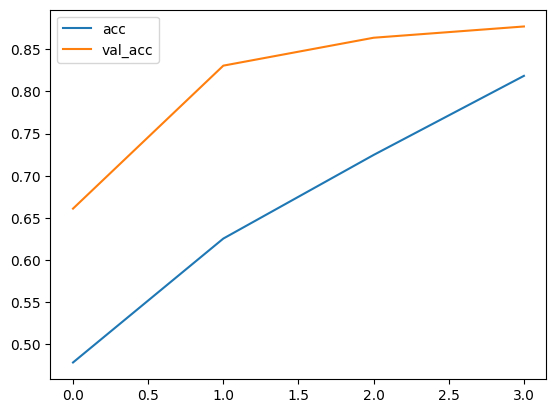

In [ ]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.legend(['acc', 'val_acc'])

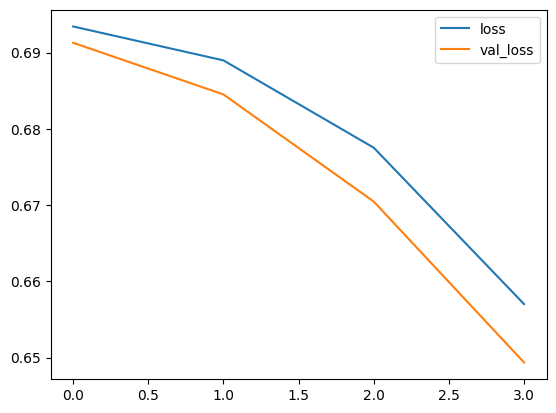

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss', 'val_loss'])